In [1]:
# CELL 1: KAGGLE SETUP AND DATASET DOWNLOAD
from google.colab import files
import os

print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Move the uploaded file to the hidden .kaggle directory where the API expects it
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading Twitter Entity Sentiment Analysis Dataset...")
# Download and unzip the dataset directly from Kaggle
!kaggle datasets download -d jp797498e/twitter-entity-sentiment-analysis --unzip
print("Download Complete! Files ready.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis
License(s): CC0-1.0
100% 1.99M/1.99M [00:00<00:00, 186MB/s]

Download Complete! Files ready.


In [2]:
# CELL 2: DATA PREPARATION & TOKENIZATION
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer

print("Loading and cleaning data...")

# Load the CSVs and assign proper column names
col_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_Text']
train_df = pd.read_csv('twitter_training.csv', names=col_names, header=None)
val_df = pd.read_csv('twitter_validation.csv', names=col_names, header=None)

# Drop rows where the tweet text is missing
train_df.dropna(subset=['Tweet_Text'], inplace=True)
val_df.dropna(subset=['Tweet_Text'], inplace=True)

# Map string sentiments to numerical integers
label_mapping = {'Negative': 0, 'Positive': 1, 'Neutral': 2, 'Irrelevant': 3}
train_df['label'] = train_df['Sentiment'].map(label_mapping)
val_df['label'] = val_df['Sentiment'].map(label_mapping)

print(f"Training examples: {len(train_df)} | Validation examples: {len(val_df)}")

# Initialize the standard BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
MAX_LEN = 64 # Tweets are short, so 64 tokens is plenty

def prepare_data(df):
    # Convert text column to a standard Python list
    texts = df['Tweet_Text'].astype(str).tolist()
    labels = df['label'].tolist()

    # Tokenize: converts words to IDs and adds padding so all arrays are exactly length 64
    encodings = tokenizer(texts, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='pt')

    return encodings['input_ids'], encodings['attention_mask'], torch.tensor(labels)

print("Tokenizing text... (this may take a minute)")
train_ids, train_masks, train_labels = prepare_data(train_df)
val_ids, val_masks, val_labels = prepare_data(val_df)

# Package the tensors into PyTorch DataLoaders to feed the GPU in batches of 64
BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(train_ids, train_masks, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(val_ids, val_masks, val_labels), batch_size=BATCH_SIZE, shuffle=False)
print("Data Loaders ready!")

Loading and cleaning data...
Training examples: 73996 | Validation examples: 1000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing text... (this may take a minute)
Data Loaders ready!


In [3]:
# CELL 3: THE TRANSFORMER ENCODER ARCHITECTURE
import math
import torch.nn as nn

class ScaledDotProductAttention(nn.Module):
    def forward(self, q, k, v, mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            # Reshape mask to broadcast across attention heads
            scores = scores.masked_fill(mask == 0, -1e9)
        attention_probs = torch.softmax(scores, dim=-1)
        return torch.matmul(attention_probs, v)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_linear = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention()

    def forward(self, x, mask=None):
        batch_size, seq_len, d_model = x.size()

        q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        attn_output = self.attention(q, k, v, mask)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        return self.out_linear(attn_output)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.layernorm1(x + self.dropout(self.mha(x, mask)))
        x = self.layernorm2(x + self.dropout(self.ffn(x)))
        return x

class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_seq_len, num_classes):
        super().__init__()
        # 1. Embeddings
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_seq_len, d_model)

        # 2. Encoder Stack
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)])

        # 3. Classification Head
        self.fc = nn.Linear(d_model, num_classes)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, mask=None):
        batch_size, seq_len = x.size()
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)

        # Add embeddings
        out = self.dropout(self.token_embedding(x) + self.pos_embedding(positions))

        # Reshape mask for attention
        if mask is not None:
            attn_mask = mask.unsqueeze(1).unsqueeze(2)
        else:
            attn_mask = None

        # Pass through layers
        for layer in self.layers:
            out = layer(out, attn_mask)

        # Mean Pooling: Average the sequence vectors
        if mask is not None:
            mask_expanded = mask.unsqueeze(-1).float()
            out = (out * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)
        else:
            out = out.mean(dim=1)

        # Final classification
        return self.fc(out)

In [6]:
# CELL 4: THE TRAINING ENGINE
from tqdm import tqdm

# Connect to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Model Configuration
VOCAB_SIZE = tokenizer.vocab_size
D_MODEL = 256     # Hidden size
NUM_LAYERS = 3    # 3 stacked layers
NUM_HEADS = 8     # 8 attention lenses
D_FF = 512        # Feed forward width
NUM_CLASSES = 4   # Neg, Pos, Neu, Irr
EPOCHS = 20       # Number of times to loop through the data

model = SentimentTransformer(VOCAB_SIZE, D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF, MAX_LEN, NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    # Training Loop
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for ids, masks, labels in progress:
        ids, masks, labels = ids.to(device), masks.to(device), labels.to(device)

        optimizer.zero_grad() # Clear old gradients
        outputs = model(ids, mask=masks) # Forward pass

        loss = criterion(outputs, labels) # Calculate error
        loss.backward() # Backpropagation (Calculate adjustments)
        optimizer.step() # Apply adjustments

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{100.*correct/total:.2f}%"})

    # Validation Loop (Testing the AI on unseen data)
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for ids, masks, labels in val_loader:
            ids, masks, labels = ids.to(device), masks.to(device), labels.to(device)
            outputs = model(ids, mask=masks)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    print(f"\n✅ Epoch {epoch+1} Completed | Train Acc: {100.*correct/total:.2f}% | Val Acc: {100.*val_correct/val_total:.2f}%\n")

Training on: cuda


Epoch 1/20: 100%|██████████| 1157/1157 [00:34<00:00, 33.58it/s, Loss=0.9542, Acc=48.36%]



✅ Epoch 1 Completed | Train Acc: 48.36% | Val Acc: 57.30%



Epoch 2/20: 100%|██████████| 1157/1157 [00:30<00:00, 38.10it/s, Loss=0.9026, Acc=56.35%]



✅ Epoch 2 Completed | Train Acc: 56.35% | Val Acc: 64.20%



...


✅ Epoch 18 Completed | Train Acc: 93.48% | Val Acc: 93.50%



Epoch 19/20: 100%|██████████| 1157/1157 [00:30<00:00, 38.08it/s, Loss=0.0618, Acc=93.89%]



✅ Epoch 19 Completed | Train Acc: 93.89% | Val Acc: 94.00%



Epoch 20/20: 100%|██████████| 1157/1157 [00:30<00:00, 38.17it/s, Loss=0.1014, Acc=94.13%]



✅ Epoch 20 Completed | Train Acc: 94.13% | Val Acc: 94.20%



In [7]:
# CELL 5: INFERENCE FUNCTION
def predict_tweet(text):
    model.eval()
    reverse_map = {0: '🔴 Negative', 1: '🟢 Positive', 2: '⚪ Neutral', 3: '🟡 Irrelevant'}

    # Process text identically to training data
    inputs = tokenizer(text, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='pt')
    ids = inputs['input_ids'].to(device)
    mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(ids, mask=mask)
        probabilities = torch.softmax(logits, dim=-1)
        prediction = torch.argmax(probabilities, dim=-1).item()

    confidence = probabilities[0][prediction].item() * 100
    print(f"Tweet: \"{text}\"")
    print(f"Prediction: {reverse_map[prediction]} ({confidence:.1f}% confident)\n")

# Try it out!
predict_tweet("The new update for this game completely broke my save files. I am furious.")
predict_tweet("Just bought the new console and I am having the absolute best time ever!")
predict_tweet("I am eating a sandwich for lunch.")

Tweet: "The new update for this game completely broke my save files. I am furious."
Prediction: 🟢 Positive (95.4% confident)

Tweet: "Just bought the new console and I am having the absolute best time ever!"
Prediction: 🟢 Positive (99.9% confident)

Tweet: "I am eating a sandwich for lunch."
Prediction: ⚪ Neutral (98.1% confident)



Evaluating model performance across all categories...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.93      0.97      0.95       266
    Positive       0.97      0.92      0.95       277
     Neutral       0.93      0.94      0.93       285
  Irrelevant       0.93      0.94      0.93       172

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



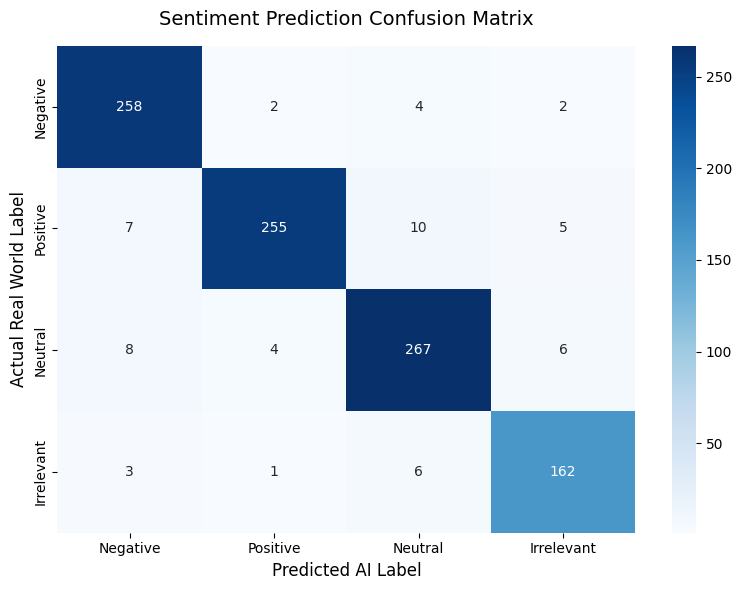

In [8]:
# CELL 6: PROFESSIONAL EVALUATION SUITE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating model performance across all categories...")

# 1. Gather all predictions and true labels from the validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for ids, masks, labels in val_loader:
        ids, masks, labels = ids.to(device), masks.to(device), labels.to(device)

        # Forward pass through your scratch transformer
        outputs = model(ids, mask=masks)
        _, predicted = outputs.max(1)

        # Move back to CPU and convert to numpy arrays for tracking
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert lists to flat numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Define our target sentiment category names
target_names = ['Negative', 'Positive', 'Neutral', 'Irrelevant']

# =====================================================================
# 2. GENERATE CLASSIFICATION REPORT (Precision, Recall, F1)
# =====================================================================
print("\n=== CLASSIFICATION REPORT ===")
report = classification_report(all_labels, all_preds, target_names=target_names)
print(report)

# =====================================================================
# 3. GENERATE AND PLOT THE CONFUSION MATRIX
# =====================================================================
# Compute the raw confusion counts
cm = confusion_matrix(all_labels, all_preds)

# Configure a clean visualization canvas
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # Write the raw numbers inside the grid squares
    fmt='d',             # Format as integers
    cmap='Blues',        # Use a professional blue color profile
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title('Sentiment Prediction Confusion Matrix', fontsize=14, pad=15)
plt.ylabel('Actual Real World Label', fontsize=12)
plt.xlabel('Predicted AI Label', fontsize=12)
plt.tight_layout()
plt.show()  # Renders the graph directly on your Colab screen

In [9]:
# CELL 7 : MOUNT DRIVE AND SAVE MODEL + EVALUATION RESULTS
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

print("Connecting to your Google Drive...")
# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define your dedicated project folder directory
save_directory = '/content/drive/MyDrive/Twitter_Sentiment_Transformer'
os.makedirs(save_directory, exist_ok=True)
print(f"📁 Project folder verified at: {save_directory}")

# 3. Save the PyTorch Model Weights
model_save_path = os.path.join(save_directory, 'sentiment_transformer_weights.pt')
torch.save(model.state_dict(), model_save_path)
print(f"💾 Model weights successfully saved to: {model_save_path}")

# 4. Save the Tokenizer Configuration
tokenizer.save_pretrained(save_directory)
print(f"📝 Tokenizer configurations successfully saved to: {save_directory}")

# =====================================================================
# NEW ADDITION: EXPORT AND SAVE DATA FROM CELL 7 ANALYTICS
# =====================================================================

# Check to ensure Cell 7 variables exist safely in your active notebook memory
if 'report' in locals() and 'cm' in locals():
    print("\nAnalyzing evaluation metrics for backup...")

    # 5. Export the text classification report to a .txt file
    report_save_path = os.path.join(save_directory, 'classification_report.txt')
    with open(report_save_path, 'w') as f:
        f.write(report)
    print(f"📄 Text metrics report successfully saved to: {report_save_path}")

    # 6. Reconstruct the Confusion Matrix plot and save it as a high-res image
    plt.figure(figsize=(8, 6))
    target_names = ['Negative', 'Positive', 'Neutral', 'Irrelevant']
    sns.heatmap(
        cm,
        annot=True,          # Overlay raw count values
        fmt='d',             # Integers format
        cmap='Blues',        # Professional blue styling spectrum
        xticklabels=target_names,
        yticklabels=target_names
    )
    plt.title('Sentiment Prediction Confusion Matrix', fontsize=14, pad=15)
    plt.ylabel('Actual Real World Label', fontsize=12)
    plt.xlabel('Predicted AI Label', fontsize=12)
    plt.tight_layout()

    # Save the chart directly to your drive path as a 300 DPI image
    plot_save_path = os.path.join(save_directory, 'confusion_matrix_chart.png')
    plt.savefig(plot_save_path, dpi=300)
    plt.close() # Closes the visual canvas window to clear memory streams
    print(f"📊 Confusion Matrix plot image saved to: {plot_save_path}")

else:
    print("\n⚠️ Warning: Cell 7 evaluation variables ('report' or 'cm') were not located in active memory.")
    print("👉 Action Required: Run Cell 7 (Evaluation Suite) first, then execute this cell to save metrics!")

print("\n🎉 Everything is safely backed up in your Google Drive! You can close Colab without losing progress.")

Connecting to your Google Drive...
Mounted at /content/drive
📁 Project folder verified at: /content/drive/MyDrive/Twitter_Sentiment_Transformer
💾 Model weights successfully saved to: /content/drive/MyDrive/Twitter_Sentiment_Transformer/sentiment_transformer_weights.pt
📝 Tokenizer configurations successfully saved to: /content/drive/MyDrive/Twitter_Sentiment_Transformer

Analyzing evaluation metrics for backup...
📄 Text metrics report successfully saved to: /content/drive/MyDrive/Twitter_Sentiment_Transformer/classification_report.txt
📊 Confusion Matrix plot image saved to: /content/drive/MyDrive/Twitter_Sentiment_Transformer/confusion_matrix_chart.png

🎉 Everything is safely backed up in your Google Drive! You can close Colab without losing progress.
